In [1]:
import pandas as pd
import numpy as np
import sys
import os
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)

### load data

In [2]:
sys.path.append(os.path.abspath(".."))
from src.db_connection import get_engine

engine = get_engine()
df = pd.read_sql("""SELECT * FROM vw_applications_ml_base""", engine)
print(df.shape)
df.head()

(239660, 20)


,appid,name,type,is_free,required_age,release_date,metacritic_score,recommendations_total,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_supports_windows,mat_supports_mac,mat_supports_linux,short_description,supported_languages,created_at,updated_at
0,10,Counter-Strike,game,0,0,2000-11-01,88.0,161854.0,999.0,999.0,0.0,USD,NaN,1,1,1,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,20,Team Fortress Classic,game,0,0,1999-04-01,NaN,6633.0,499.0,499.0,0.0,USD,NaN,1,1,1,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,30,Day of Defeat,game,0,0,2003-05-01,79.0,4308.0,499.0,499.0,0.0,USD,NaN,1,1,1,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
3,40,Deathmatch Classic,game,0,0,2001-06-01,NaN,2338.0,499.0,499.0,0.0,USD,NaN,1,1,1,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
4,50,Half-Life: Opposing Force,game,0,0,1999-11-01,NaN,22793.0,499.0,499.0,0.0,USD,NaN,1,1,1,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


In [3]:
df.columns

Index(['appid', 'name', 'type', 'is_free', 'required_age', 'release_date',
       'metacritic_score', 'recommendations_total', 'mat_initial_price',
       'mat_final_price', 'mat_discount_percent', 'mat_currency',
       'mat_achievement_count', 'mat_supports_windows', 'mat_supports_mac',
       'mat_supports_linux', 'short_description', 'supported_languages',
       'created_at', 'updated_at'],
      dtype='str')

### copy data để xử lý

In [4]:
df_clean = df.copy()

### 1. xử lý missing values

- drop những cột thiếu quá nhiều (>70%)

In [5]:
missing_percent = df_clean.isnull().mean() * 100

cols_to_drop = missing_percent[missing_percent > 70].index
print("Columns to drop:", cols_to_drop)

df_clean.drop(columns=cols_to_drop, inplace=True)

Columns to drop: Index(['metacritic_score', 'recommendations_total', 'mat_achievement_count'], dtype='str')


- check lại

In [6]:
df_clean.shape

(239660, 17)

- xử lý missing cho các cột quan trọng

In [7]:
# Xử lý giá trị thiếu (null) cho dataframe
df_clean = df_clean.fillna({
    # price → fill 0
    'mat_final_price': 0,
    'mat_initial_price': 0,
    'mat_discount_percent': 0,
    
    # text → fill unknown
    'type': 'unknown',
    'supported_languages': 'unknown'
})

# release_date → giữ lại (xử lý sau)

### 2. Chuyển đổi Data type

- Convert required_age

In [8]:
# chuyển sang kiểu số, các giá trị lỗi sẽ thành NaN
df_clean['required_age'] = pd.to_numeric(df_clean['required_age'], errors='coerce')

# điền 0 vào các vị trí NaN và gán ngược lại vào cột
df_clean['required_age'] = df_clean['required_age'].fillna(0)

- Convert release_date

In [9]:
# chuyển đổi sang datetime
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')

# tạo feature mới và xử lý luôn giá trị null
df_clean['release_year'] = df_clean['release_date'].dt.year.fillna(0).astype(int)
df_clean['release_month'] = df_clean['release_date'].dt.month.fillna(0).astype(int)

### 3. Feature Engineering

- Feature: has_discount

In [10]:
df_clean['has_discount'] = df_clean['mat_discount_percent'] > 0

- Feature: price_category

In [11]:
def price_category(price):
    if price == 0:
        return 'free'
    elif price < 1000:
        return 'cheap'
    elif price < 3000:
        return 'medium'
    else:
        return 'expensive'

df_clean['price_category'] = df_clean['mat_final_price'].apply(price_category)

- Feature: platform_count

In [12]:
df_clean['platform_count'] = (
    df_clean['mat_supports_windows'].astype(int) +
    df_clean['mat_supports_mac'].astype(int) +
    df_clean['mat_supports_linux'].astype(int)
)

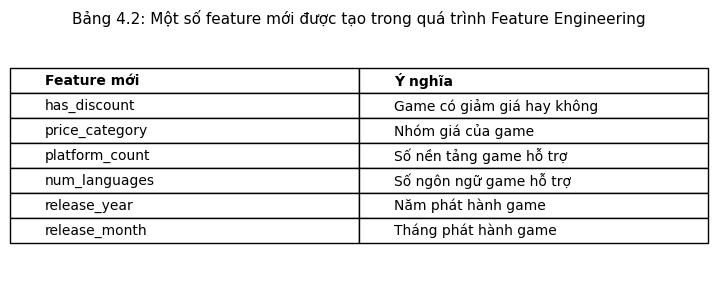

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

table_data = pd.DataFrame({
    "Feature mới": [
        "has_discount",
        "price_category",
        "platform_count",
        "num_languages",
        "release_year",
        "release_month"
    ],
    "Ý nghĩa": [
        "Game có giảm giá hay không",
        "Nhóm giá của game",
        "Số nền tảng game hỗ trợ",
        "Số ngôn ngữ game hỗ trợ",
        "Năm phát hành game",
        "Tháng phát hành game"
    ]
})

fig, ax = plt.subplots(figsize=(9, 3))
ax.axis('off')

tbl = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='left',
    colLoc='left',
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

for i in range(len(table_data.columns)):
    tbl[(0, i)].set_text_props(weight='bold')

plt.title("Bảng 4.2: Một số feature mới được tạo trong quá trình Feature Engineering", fontsize=11, pad=12)
plt.show()

### 4. Loại cột không cần thiết

- Drop cột không dùng

In [14]:
cols_drop = [
    'name',
    'short_description',
    'header_image',
    'background',
    'release_date',
    'created_at',
    'updated_at'
]

df_clean.drop(columns=cols_drop, inplace=True, errors='ignore')

### 5. Encode Data

- One-hot encoding

In [15]:
df_encoded = pd.get_dummies(df_clean, columns=['type', 'price_category'], drop_first=True)

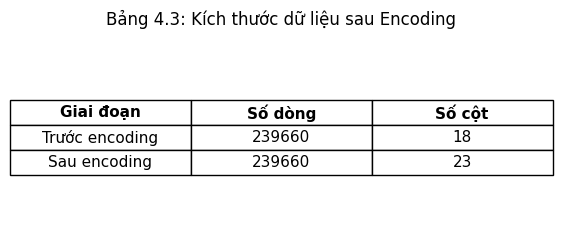

<Figure size 640x480 with 0 Axes>

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

encoding_shape_table = pd.DataFrame({
    "Giai đoạn": [
        "Trước encoding",
        "Sau encoding"
    ],
    "Số dòng": [
        df_clean.shape[0],
        df_encoded.shape[0]
    ],
    "Số cột": [
        df_clean.shape[1],
        df_encoded.shape[1]
    ]
})

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.axis("off")

table = ax.table(
    cellText=encoding_shape_table.values,
    colLabels=encoding_shape_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)

for col in range(len(encoding_shape_table.columns)):
    table[(0, col)].set_text_props(weight="bold")

plt.title(
    "Bảng 4.3: Kích thước dữ liệu sau Encoding",
    fontsize=12,
    pad=12
)

plt.show()
plt.savefig("../reports/encoding_shape_table.png", dpi=300, bbox_inches="tight")

### 6. Chuẩn hóa (Scaling)

- Chọn numeric columns

In [16]:
numeric_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns

- Scale dữ liệu

In [17]:
scaler = StandardScaler()

df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

- Xử lý supported_languages
    - trích xuất số lượng ngôn ngữ

In [18]:
import re

def count_languages(text):
    if pd.isna(text):
        return 0
    # bỏ HTML tags
    clean_text = re.sub('<.*?>', '', text)
    langs = clean_text.split(',')
    return len(langs)

df_clean['num_languages'] = df_clean['supported_languages'].apply(count_languages)

- loại bỏ toàn bộ cột text

In [19]:
df_pca_input = df_clean.select_dtypes(include=['int64', 'float64', 'bool']).copy()

- Convert bool → int

In [20]:
df_pca_input = df_pca_input.astype(float)

- Fill missing

In [21]:
df_pca_input = df_pca_input.fillna(0)

- Scaling

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca_input)

### 7. PCA

- Áp dụng PCA

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Before PCA:", X_scaled.shape)
print("After PCA:", X_pca.shape)

Before PCA: (239660, 14)
After PCA: (239660, 9)


- Explained variance

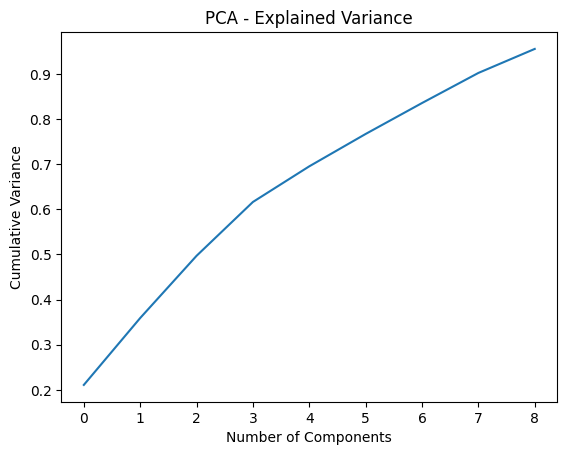

In [24]:
import numpy as np
import matplotlib.pyplot as plt

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA - Explained Variance")
plt.show()

Sau khi áp dụng PCA với ngưỡng giữ lại 95% phương sai, số chiều dữ liệu đã giảm đáng kể. Điều này giúp mô hình học nhanh hơn, giảm overfitting và loại bỏ sự dư thừa giữa các biến.

In [25]:
X_pca

array([[-0.03214238,  0.74692209, -0.03480928, ...,  0.0911602 ,
        -0.87051131, -0.7427516 ],
       [ 0.01187677,  0.23487051, -0.01376113, ...,  0.06524084,
        -0.68663374, -1.38066842],
       [ 0.00597687,  0.26599071, -0.01354922, ...,  0.05683674,
        -0.56351143, -1.19326721],
       ...,
       [ 0.23160666, -2.14030426,  0.0749091 , ..., -0.17471255,
         1.49634439, -0.29027411],
       [ 0.10852075, -0.58458775,  0.00973786, ..., -0.12659752,
         1.12790807,  0.86395134],
       [ 0.10867437, -0.59609594,  0.01063759, ..., -0.12974554,
         1.16675245,  0.88933085]], shape=(239660, 9))

## Kết luận

## 1. Nguồn dữ liệu

Data được lấy từ MySQL thông qua view `vw_applications_ml_base`. View này đóng vai trò là nguồn dữ liệu nền cho quá trình preprocessing và xây dựng dữ liệu đầu vào cho các mô hình ML.

## 2. Xử lý missing values

Trong quá trình preprocessing, các cột có tỷ lệ missing values quá cao được loại bỏ để tránh ảnh hưởng tiêu cực đến mô hình.

Các chiến lược xử lý chính gồm:

- Loại bỏ các cột thiếu quá nhiều dữ liệu.
- Fill các cột giá trị số quan trọng bằng giá trị phù hợp, ví dụ như `0`.
- Fill các cột categorical bằng giá trị `"unknown"` nếu cần.
- Kiểm tra lại missing values sau khi xử lý để đảm bảo dữ liệu có thể dùng cho mô hình.


## 3. Chuyển đổi kiểu dữ liệu

Một số cột trong dataset ban đầu chưa có kiểu dữ liệu phù hợp, vì vậy cần chuyển đổi trước khi đưa vào mô hình:

- `required_age` được chuyển sang dạng numeric.
- `release_date` được chuyển sang dạng datetime.
- Từ `release_date`, có thể tạo thêm các đặc trưng như:
  - `release_year`
  - `release_month`

Việc chuyển đổi kiểu dữ liệu giúp dữ liệu nhất quán hơn và hỗ trợ tốt hơn cho các bước feature engineering.


## 4. Feature Engineering

Một số đặc trưng mới được tạo ra nhằm giúp mô hình khai thác dữ liệu hiệu quả hơn, bao gồm:

- `has_discount`: cho biết game có đang được giảm giá hay không.
- `price_category`: phân loại game theo mức giá.
- `platform_count`: số lượng nền tảng mà game hỗ trợ.
- `num_languages`: số lượng ngôn ngữ được hỗ trợ, được trích xuất từ cột `supported_languages`.

Các feature này giúp bổ sung thêm thông tin có ý nghĩa cho các bài toán regression, classification và clustering.


## 5. Encoding

Các biến categorical được chuyển đổi sang dạng số bằng One-Hot Encoding.

Một số cột categorical được xử lý gồm:

- `type`
- `price_category`
- các cột categorical khác nếu còn tồn tại sau bước làm sạch

Việc encoding là cần thiết vì hầu hết các thuật toán Machine Learning không thể xử lý trực tiếp dữ liệu dạng chuỗi.


## 6. Scaling

Dữ liệu numeric được chuẩn hóa bằng `StandardScaler`.

Mục đích của scaling:

- Đưa các feature về cùng thang đo.
- Tránh việc các feature có giá trị lớn chi phối mô hình.
- Chuẩn bị dữ liệu phù hợp cho PCA và các thuật toán dựa trên khoảng cách.


## 7. PCA

PCA được áp dụng để giảm số chiều dữ liệu nhưng vẫn giữ lại khoảng 95% phương sai.

Việc sử dụng PCA giúp:

- Giảm nhiễu trong dữ liệu.
- Giảm độ phức tạp của dữ liệu đầu vào.
- Tăng tốc độ huấn luyện mô hình.
- Hỗ trợ tốt hơn cho bước clustering và visualization.


## 8. Kết quả đầu ra

Sau khi hoàn thành preprocessing và PCA, notebook tạo ra hai file dữ liệu trong thư mục `data/processed/`:

- `clean_data.csv`: dữ liệu đã được làm sạch, xử lý missing values, encoding và sẵn sàng cho regression/classification.
- `pca_data.csv`: dữ liệu sau khi áp dụng PCA, được sử dụng cho clustering.

Hai file này giúp các notebook phía sau sử dụng dữ liệu nhất quán, tránh phải xử lý lại từ đầu.


## 9. Kết luận chung

Sau bước preprocessing, dữ liệu đã được làm sạch và chuyển đổi sang dạng phù hợp cho ML. Các bước xử lý như missing value handling, datatype conversion, feature engineering, encoding, scaling và PCA giúp tạo ra một pipeline dữ liệu hoàn chỉnh.

In [26]:
# Save clean data
df_clean.to_csv("../data/processed/clean_data.csv", index=False)

# Save PCA
pd.DataFrame(X_pca).to_csv("../data/processed/pca_data.csv", index=False)

In [27]:
import joblib
#Cho giao diện
joblib.dump(scaler, '../src/models/scaler.pkl')
joblib.dump(pca, '../src/models/pca.pkl')

['../src/models/pca.pkl']